# Point Synapse drive demo

This notebook builds a tiny hand-written morphology, places point synapses on `soma(0.5)`, manually drives them through the runtime `pre_spike` state, and plots the resulting synaptic state / synaptic current / voltage traces.

The first AMPA example is intentionally configured to look like a clean single-exponential decay after a **single spike**.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import brainstate
import brainunit as u
import jax.numpy as jnp

os.environ.setdefault("JAX_PLATFORMS", "cpu")


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import braincell
from braincell import Branch, Morphology, Cell, CVPerBranch
import braincell.mech as mech
from braincell.filter import at

print("braincell version:", braincell.__version__)
print("repo_root:", repo_root)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


braincell version: 0.1.0
repo_root: /home/swl/braincell


In [2]:
def build_demo_morphology():
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    dend = Branch.from_lengths(
        lengths=[120.0] * u.um,
        radii=[2.5, 1.5] * u.um,
        type="basal_dendrite",
    )
    morph = Morphology.from_root(soma, name="soma")
    morph.soma.dend = dend
    return morph


def run_synapse_drive_demo(
    synapse_type,
    synapse_name,
    synapse_params,
    *,
    spike_steps=(10,),
    dt=0.05 * u.ms,
    n_steps=120,
    include_x=False,
):
    cell = Cell(
        build_demo_morphology(),
        cv_policy=CVPerBranch(),
        solver="staggered",
        V_init=-65.0 * u.mV,
    )
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    cell.place(at("soma", 0.5), mech.MechanismProbe(name="g", mechanism=synapse_name, field="g"))
    if include_x:
        cell.place(at("soma", 0.5), mech.MechanismProbe(name="x", mechanism=synapse_name, field="x"))
    cell.place(at("soma", 0.5), mech.CurrentProbe(name="i_syn", mechanism=synapse_name))
    cell.place(
        at("soma", 0.5),
        mech.Synapse(synapse_type, name=synapse_name, **synapse_params),
    )
    cell.init_state()

    runtime = cell.runtime
    layout = next(layout for layout in runtime.layouts if layout.kind == f"synapse:{synapse_type}")

    times_ms = []
    pre_spike = []
    voltage_mv = []
    g_values = []
    x_values = []
    i_syn_values = []

    for step in range(n_steps):
        t = step * dt
        drive = 1.0 if step in spike_steps else 0.0
        runtime.set_state(layout.id, "pre_spike", drive)
        with brainstate.environ.context(t=t, dt=dt):
            cell.update()
        sample = cell.sample_probes()
        times_ms.append(float(t.to_decimal(u.ms)))
        pre_spike.append(drive)
        voltage_mv.append(float(sample["v"].to_decimal(u.mV)))
        g_values.append(float(sample["g"]))
        if include_x:
            x_values.append(float(sample["x"]))
        i_syn_values.append(float(sample["i_syn"].to_decimal(u.nA / u.cm ** 2)))

    return {
        "cell": cell,
        "layout_id": layout.id,
        "times_ms": times_ms,
        "pre_spike": pre_spike,
        "v_mV": voltage_mv,
        "g": g_values,
        "x": x_values,
        "i_syn": i_syn_values,
    }


In [3]:
ampa = run_synapse_drive_demo(
    "AMPA",
    "ampa_soma",
    {
        "g_max": 0.05 * (u.mS / u.cm ** 2),
        "E_rev": 0.0 * u.mV,
        "alpha": 1.0 / u.ms,
        "beta": 2.0 / u.ms,
    },
    spike_steps=(10,),
)

print("AMPA layout id:", ampa["layout_id"])
print("AMPA peak g:", max(ampa["g"]))
print("AMPA peak current (nA/cm^2):", max(ampa["i_syn"]))


AMPA layout id: 3
AMPA peak g: 0.02350061759352684
AMPA peak current (nA/cm^2): 76.37745666503906


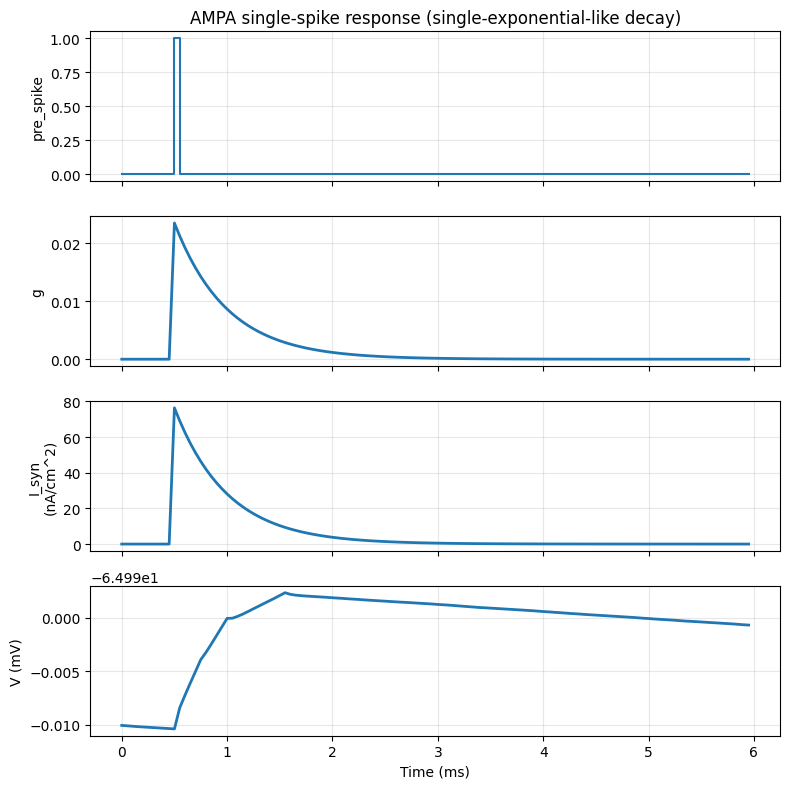

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axes[0].step(ampa["times_ms"], ampa["pre_spike"], where="post")
axes[0].set_ylabel("pre_spike")
axes[0].set_title("AMPA single-spike response (single-exponential-like decay)")

axes[1].plot(ampa["times_ms"], ampa["g"], linewidth=2)
axes[1].set_ylabel("g")

axes[2].plot(ampa["times_ms"], ampa["i_syn"], linewidth=2)
axes[2].set_ylabel("I_syn\n(nA/cm^2)")

axes[3].plot(ampa["times_ms"], ampa["v_mV"], linewidth=2)
axes[3].set_ylabel("V (mV)")
axes[3].set_xlabel("Time (ms)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
nmda = run_synapse_drive_demo(
    "NMDA",
    "nmda_soma",
    {
        "g_max": 0.15 * (u.mS / u.cm ** 2),
        "E_rev": 0.0 * u.mV,
    },
    spike_steps=(10, 20,),
    include_x=True,
)

print("NMDA layout id:", nmda["layout_id"])
print("NMDA peak x:", max(nmda["x"]))
print("NMDA peak g:", max(nmda["g"]))
print("NMDA peak current (nA/cm^2):", max(nmda["i_syn"]))


NMDA layout id: 4
NMDA peak x: 0.08385695517063141
NMDA peak g: 0.2880525290966034
NMDA peak current (nA/cm^2): 2607.0107421875


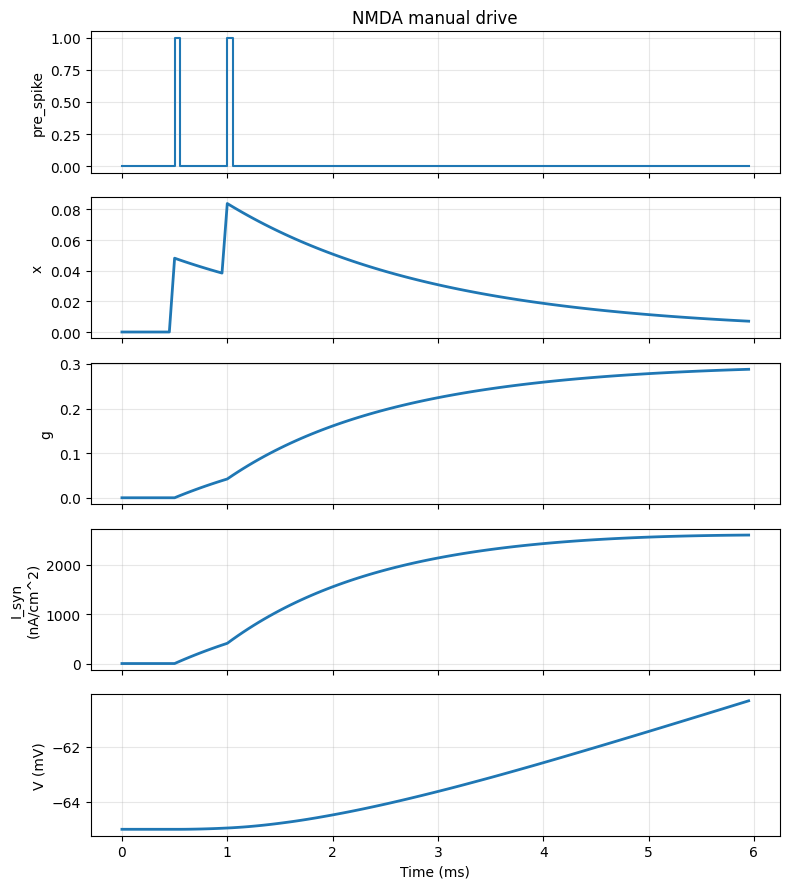

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(8, 9), sharex=True)
axes[0].step(nmda["times_ms"], nmda["pre_spike"], where="post")
axes[0].set_ylabel("pre_spike")
axes[0].set_title("NMDA manual drive")

axes[1].plot(nmda["times_ms"], nmda["x"], linewidth=2)
axes[1].set_ylabel("x")

axes[2].plot(nmda["times_ms"], nmda["g"], linewidth=2)
axes[2].set_ylabel("g")

axes[3].plot(nmda["times_ms"], nmda["i_syn"], linewidth=2)
axes[3].set_ylabel("I_syn\n(nA/cm^2)")

axes[4].plot(nmda["times_ms"], nmda["v_mV"], linewidth=2)
axes[4].set_ylabel("V (mV)")
axes[4].set_xlabel("Time (ms)")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
